In [1]:
from tqdm import tqdm

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

In [2]:
# Device
device = "cuda" if torch.cuda.is_available() else "cpu"

# ----------------------------
# Model
# ----------------------------
class PINN2D(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

    def forward(self, x, y, t):
        return self.net(torch.cat([x, y, t], dim=1))


In [3]:
# ----------------------------
# Physics residual
# ----------------------------
def physics_loss(model, x, y, t, lam):

    x.requires_grad_(True)
    y.requires_grad_(True)
    t.requires_grad_(True)

    phi = model(x, y, t)

    phi_t = torch.autograd.grad(phi, t, torch.ones_like(phi), create_graph=True)[0]
    phi_tt = torch.autograd.grad(phi_t, t, torch.ones_like(phi_t), create_graph=True)[0]

    phi_x = torch.autograd.grad(phi, x, torch.ones_like(phi), create_graph=True)[0]
    phi_xx = torch.autograd.grad(phi_x, x, torch.ones_like(phi_x), create_graph=True)[0]

    phi_y = torch.autograd.grad(phi, y, torch.ones_like(phi), create_graph=True)[0]
    phi_yy = torch.autograd.grad(phi_y, y, torch.ones_like(phi_y), create_graph=True)[0]

    nonlinear = lam * phi * (phi**2 - 1)

    residual = phi_tt - phi_xx - phi_yy + nonlinear

    return torch.mean(residual**2)


# ----------------------------
# Initial conditions
# ----------------------------
def initial_loss(model, x, y):

    t0 = torch.zeros_like(x)

    x.requires_grad_(True)
    y.requires_grad_(True)
    t0.requires_grad_(True)

    phi = model(x, y, t0)

    phi_t = torch.autograd.grad(phi, t0, torch.ones_like(phi), create_graph=True)[0]

    phi0 = 0.5*torch.exp(-4*(x**2 + y**2))

    loss_phi = torch.mean((phi - phi0)**2)
    loss_phit = torch.mean(phi_t**2)

    return loss_phi + loss_phit

In [4]:
# ----------------------------
# Parameters
# ----------------------------
lam = 1.0
T = 1.0

model = PINN2D().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer=optimizer, step_size=1500)

# ----------------------------
# Training
# ----------------------------
epochs = 4000

for epoch in tqdm(range(epochs), desc="solving"):

    # Collocation
    x_f = (2*torch.rand(3000,1)-1).to(device)
    y_f = (2*torch.rand(3000,1)-1).to(device)
    t_f = (torch.rand(3000,1)*T).to(device)

    # Initial
    x_i = (2*torch.rand(800,1)-1).to(device)
    y_i = (2*torch.rand(800,1)-1).to(device)

    loss_f = physics_loss(model, x_f, y_f, t_f, lam)
    loss_i = initial_loss(model, x_i, y_i)

    loss = loss_f + loss_i

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()

    # if epoch % 500 == 0:
    #     print(f"Epoch {epoch}, Loss {loss.item():.6e}")

solving: 100%|██████████| 4000/4000 [02:20<00:00, 28.49it/s]


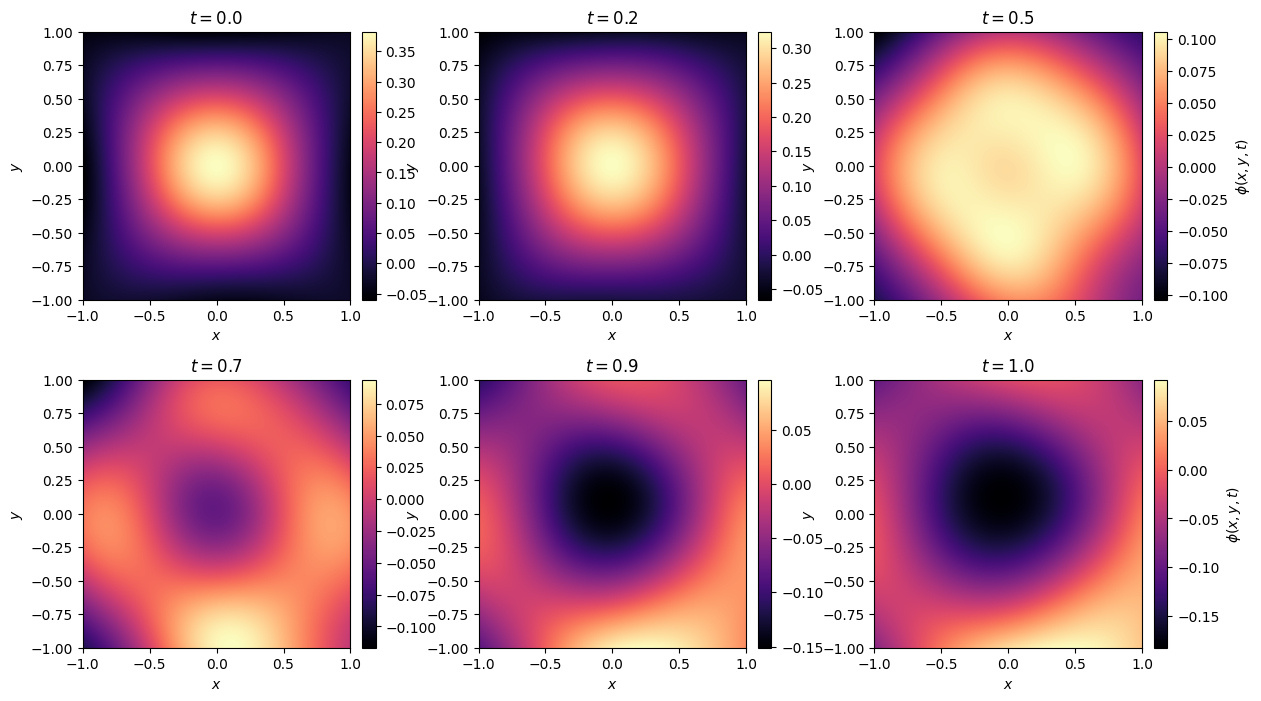

In [9]:
# ----------------------------
# Evolution snapshots (clean colorbars)
# ----------------------------
model.eval()

Nx = 1000
x = np.linspace(-1,1,Nx)
y = np.linspace(-1,1,Nx)
X, Y = np.meshgrid(x,y)

times = [0.0, 0.2, 0.5, 0.7, 0.9, 1.0]
PHI_list = []

x_tensor = torch.tensor(X.reshape(-1,1), dtype=torch.float32).to(device)
y_tensor = torch.tensor(Y.reshape(-1,1), dtype=torch.float32).to(device)

with torch.no_grad():
    for t_snapshot in times:
        t_tensor = torch.ones_like(x_tensor) * t_snapshot
        PHI = model(x_tensor, y_tensor, t_tensor).cpu().numpy().reshape(Nx,Nx)
        PHI_list.append(PHI)

fig, axes = plt.subplots(2, 3, figsize=(14,8))

for idx, (ax, PHI, t_snapshot) in enumerate(zip(axes.flat, PHI_list, times)):

    im = ax.imshow(
        PHI,
        extent=[-1,1,-1,1],
        origin='lower',
        cmap='magma'
    )

    ax.set_title(rf"$t={t_snapshot}$")
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")

    # Add colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Only label colorbars in the right column
    if idx % 3 == 2:  # rightmost column (index 2 and 5)
        cbar.set_label(r"$\phi(x,y,t)$")

plt.subplots_adjust(wspace=0.35, hspace=0.3)

plt.savefig("wave_field_eq.pdf", dpi=300, bbox_inches='tight')
plt.show()

making figures: 100%|██████████| 1000/1000 [17:56<00:00,  1.08s/it]


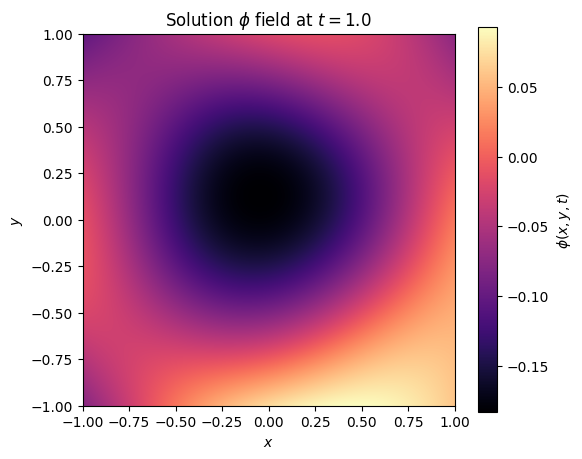

In [6]:
# ----------------------------
# Visualization video
# ----------------------------
model.eval()

Nx = 1000
x = np.linspace(-1,1,Nx)
y = np.linspace(-1,1,Nx)
X, Y = np.meshgrid(x,y)

time_domain = np.linspace(0, 1, 1000)

for i in tqdm(range(time_domain.shape[0]), desc="making figures"):

    t_snapshot = time_domain[i]

    x_tensor = torch.tensor(X.reshape(-1,1), dtype=torch.float32).to(device)
    y_tensor = torch.tensor(Y.reshape(-1,1), dtype=torch.float32).to(device)
    t_tensor = torch.ones_like(x_tensor)*t_snapshot

    with torch.no_grad():
        PHI = model(x_tensor, y_tensor, t_tensor).cpu().numpy().reshape(Nx,Nx)

    plt.close()

    plt.figure(figsize=(6,5))
    plt.imshow(PHI, extent=[-1,1,-1,1], origin='lower', cmap='magma')
    plt.xlabel(r"$x$")
    plt.ylabel(r"$y$")
    plt.title(r"Solution $\phi$ field at $t=$" + f"{np.round(t_snapshot, decimals=2)}")
    plt.colorbar(label=r"$\phi (x,y,t)$")

    plt.savefig(f"wave_field_eq_{i}.png", dpi=300, bbox_inches='tight')